# LAMOST CN-Star Binary Classification\n
\n
**FT_cands-augmented ensemble classifier** for detecting CN-enhanced stars in LAMOST DR13.\n
\n
- **Seed**: FT_cands (42 literature CN-star candidates, 15 matched to dataset)\n
- **Augmentation**: Gaussian noise + RV jitter + continuum tilt + mixup + depth scaling\n
- **Validation**: GCS (29 globular cluster) + CNstar (106 field), held out entirely\n
- **Encoders**: Conv1D (raw spectra 3800-5000A) and MLP (12-D physics features)

## 1. Setup & Imports

In [8]:
import sys, os
from pathlib import Path

# Robust project-root detection: walk up until we find Deep/data.py
_p = Path.cwd().resolve()
for _ in range(5):
    if (_p / "Deep" / "data.py").exists():
        break
    _p = _p.parent
PROJECT_ROOT = _p
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': False})

from BinaryClassifier import (
    run_pipeline, augment_spectra,
    BinaryClassifier, SpectralConvEncoder, PhysicsMLPEncoder,
    BinaryTrainer, EnsembleTrainer,
    evaluate_ensemble, export_candidates,
    slice_wave_range, WAVE_START, WAVE_END,
)
from Deep.data import SpectraDataset, load_spectra_data

print(f"Project root: {PROJECT_ROOT}")
print("All imports OK")

Project root: D:\资料\2026大创\Lamost
All imports OK


## 2. Data Loading\n
\n
Load LAMOST DR13 spectra, label only FT_cands as positive, slice to 3800-5000A.

In [9]:
common_wave_full = np.arange(3710.0, 8890.0, 1.0)

dataset_full = load_spectra_data(
    stars_csv=str(PROJECT_ROOT / "stars.csv"),
    spectra_folder=str(PROJECT_ROOT / "dr13_new"),
    cn_catalogs=[str(PROJECT_ROOT / "FT_cands.csv")],
    common_wave=common_wave_full,
    seg_width=200.0,
    verbose=True,
)

X_sliced, wave = slice_wave_range(dataset_full.X, common_wave_full, WAVE_START, WAVE_END)
dataset = SpectraDataset(
    X=X_sliced, y=dataset_full.y.copy(),
    meta=dataset_full.meta.copy(), wave=wave,
)

print(f"\nSliced: {X_sliced.shape} spectra x {X_sliced.shape[1]} pixels")
print(f"Wavelength range: {wave[0]:.0f} - {wave[-1]:.0f} A")
print(f"FT_cands labeled (y=1): {dataset.n_positive}")
print(f"Unlabeled (y=-1): {dataset.n_unlabeled}")

Loading LAMOST spectra (segment normalisation)


100%|██████████| 48440/48440 [18:51<00:00, 42.81it/s] 



Pipeline summary:
  n_input: 48440
  n_after_dropna: 48440
  n_positive_labeled: 20
  n_loaded: 37086
  n_normalized_ok: 37086
  n_after_uid_dedup: 34123
  n_after_anomaly_filter: 33512
  n_positive (final): 15
  n_unlabeled (final): 33497
  Spectra shape: (33512, 5180)

Sliced: (33512, 1201) spectra x 1201 pixels
Wavelength range: 3800 - 5000 A
FT_cands labeled (y=1): 15
Unlabeled (y=-1): 33497


## 3. Data Overview — Spectra Visualization

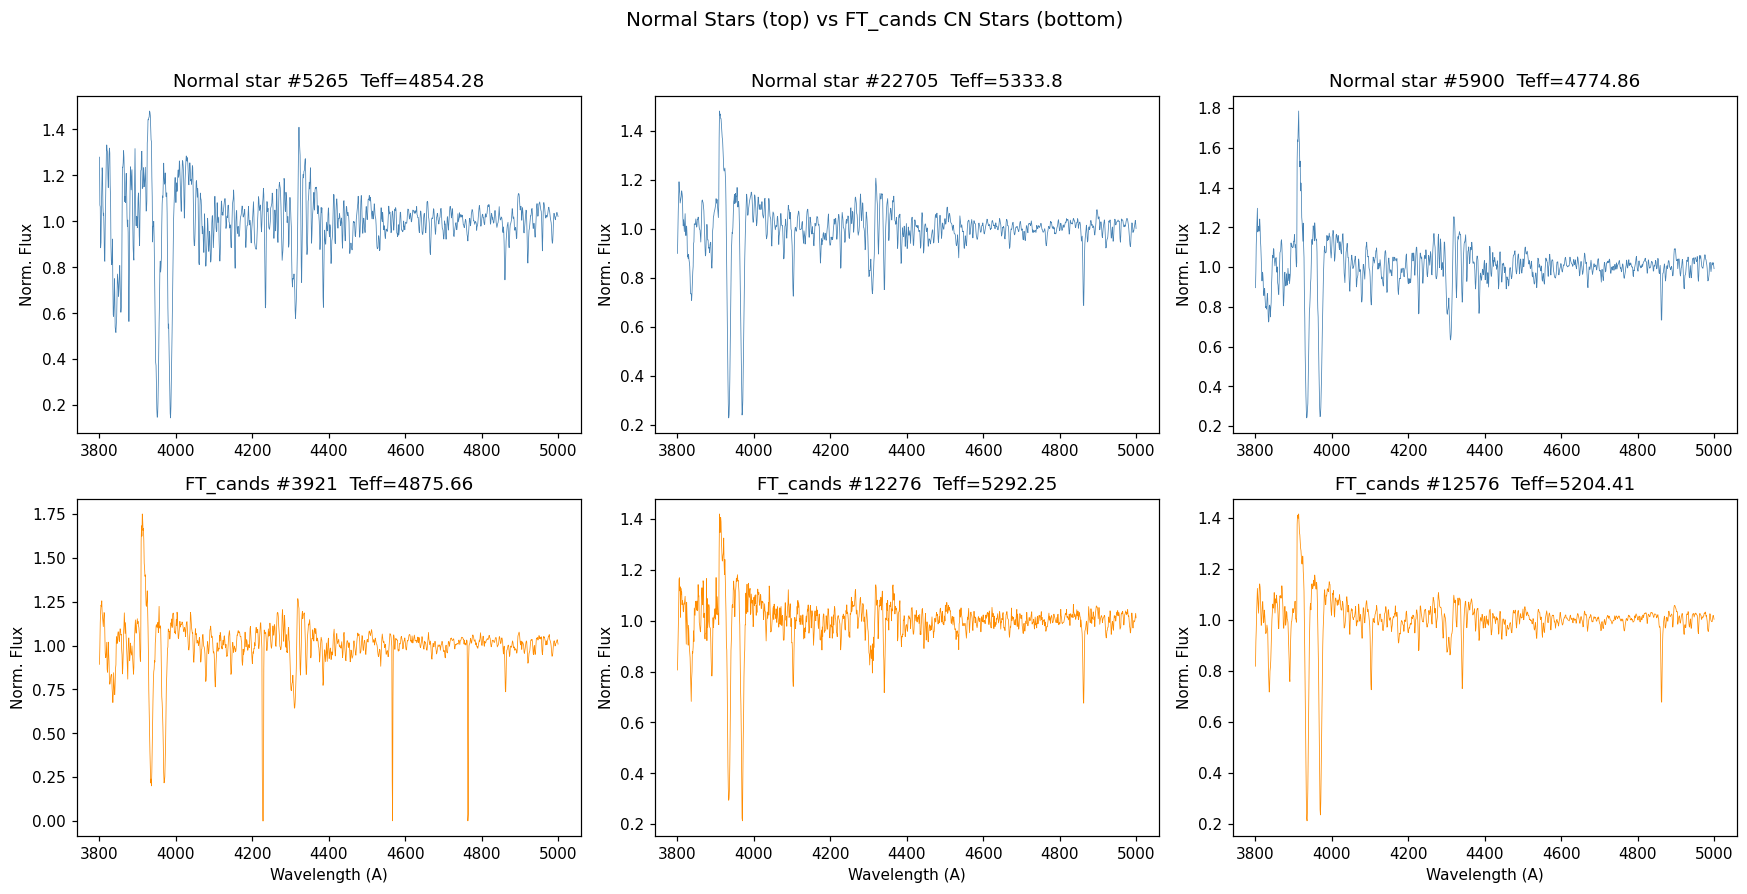

In [10]:
# Show random normal stars + all FT_cands CN stars
pos_mask = dataset.y == 1
neg_mask = dataset.y == -1
neg_indices = np.random.RandomState(0).choice(np.where(neg_mask)[0], 6, replace=False)
pos_indices = np.where(pos_mask)[0]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Row 1: random normal stars
for ax, idx in zip(axes[0], neg_indices):
    ax.plot(wave, dataset.X[idx], lw=0.5, color='steelblue')
    ax.set_title(f"Normal star #{idx}  Teff={dataset.meta.iloc[idx].get('teff','?')}")
    ax.set_ylabel("Norm. Flux")

# Row 2: FT_cands (CN stars)
for ax, idx in zip(axes[1], pos_indices):
    ax.plot(wave, dataset.X[idx], lw=0.5, color='darkorange')
    ax.set_title(f"FT_cands #{idx}  Teff={dataset.meta.iloc[idx].get('teff','?')}")
    ax.set_xlabel("Wavelength (A)")
    ax.set_ylabel("Norm. Flux")

fig.suptitle("Normal Stars (top) vs FT_cands CN Stars (bottom)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

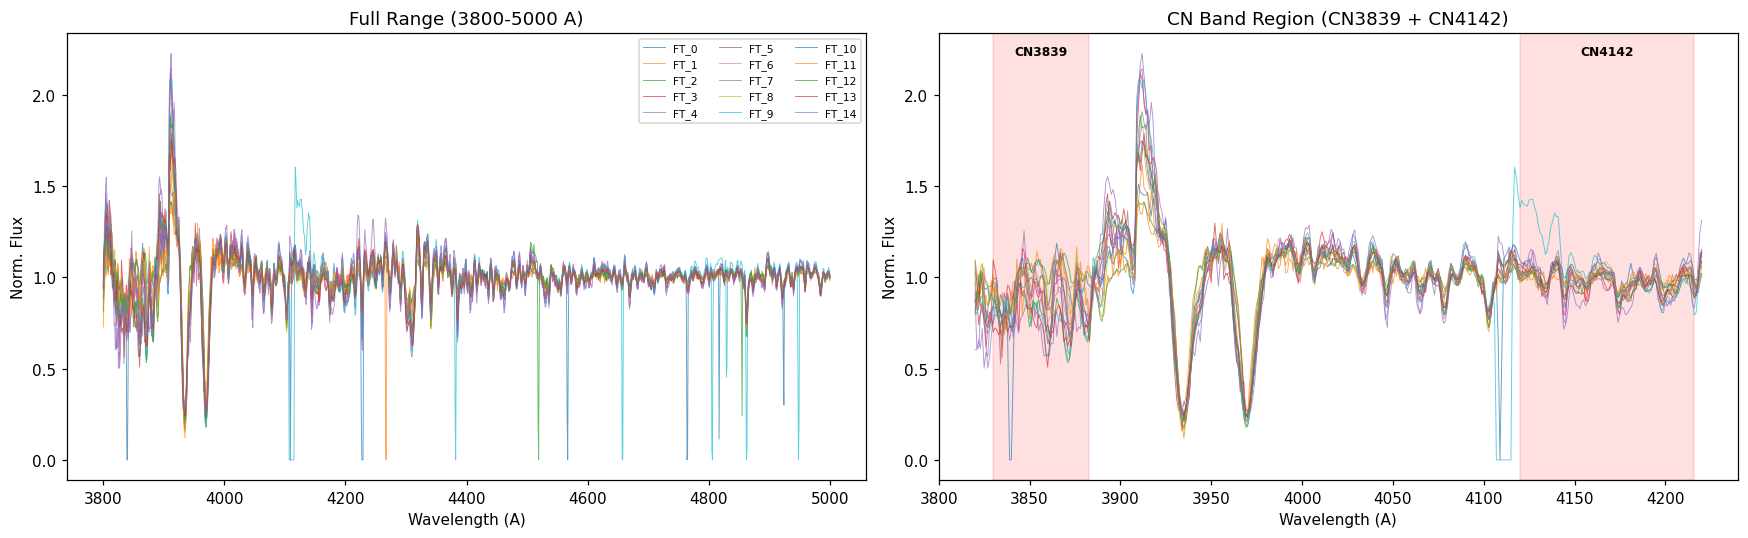

In [11]:
# Overlay all 15 FT_cands spectra to see CN band features
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, w_range, title in [
    (axes[0], (3800, 5000), "Full Range (3800-5000 A)"),
    (axes[1], (3820, 4220), "CN Band Region (CN3839 + CN4142)"),
]:
    wm = (wave >= w_range[0]) & (wave <= w_range[1])
    for i, idx in enumerate(pos_indices):
        ax.plot(wave[wm], dataset.X[idx][wm], lw=0.6, alpha=0.7,
                label=f"FT_{i}" if w_range[0] == 3800 else None)
    ax.set_title(title)
    ax.set_xlabel("Wavelength (A)")
    ax.set_ylabel("Norm. Flux")
    if w_range[0] == 3800:
        ax.legend(fontsize=7, ncol=3)
    # Mark CN band regions
    if w_range[0] == 3820:
        for band_start, band_end, label in [(3830, 3883, "CN3839"), (4120, 4216, "CN4142")]:
            ax.axvspan(band_start, band_end, alpha=0.12, color='red')
            ax.text((band_start+band_end)/2, ax.get_ylim()[1]*0.95, label,
                    ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Augmentation Demo\n
\n
Show how we expand 15 FT_cands seed spectra into ~555 training positives.

In [12]:
X_ft = dataset.X[pos_mask]
X_ft_aug, _ = augment_spectra(
    X_ft, wave,
    n_noise=12, n_rv=6, n_tilt=4, n_mixup=8, n_depth=6,
    noise_std=0.005, random_seed=42,
)
print(f"Seed: {len(X_ft)}  ->  Augmented: {len(X_ft_aug)}  (x{len(X_ft_aug)/len(X_ft):.1f})")
print(f"Layout: {len(X_ft)} originals + {12*len(X_ft)} noise + {6*len(X_ft)} RV"
      f" + {4*len(X_ft)} tilt + {8*len(X_ft)} mixup + {6*len(X_ft)} depth")

Seed: 15  ->  Augmented: 555  (x37.0)
Layout: 15 originals + 180 noise + 90 RV + 60 tilt + 120 mixup + 90 depth


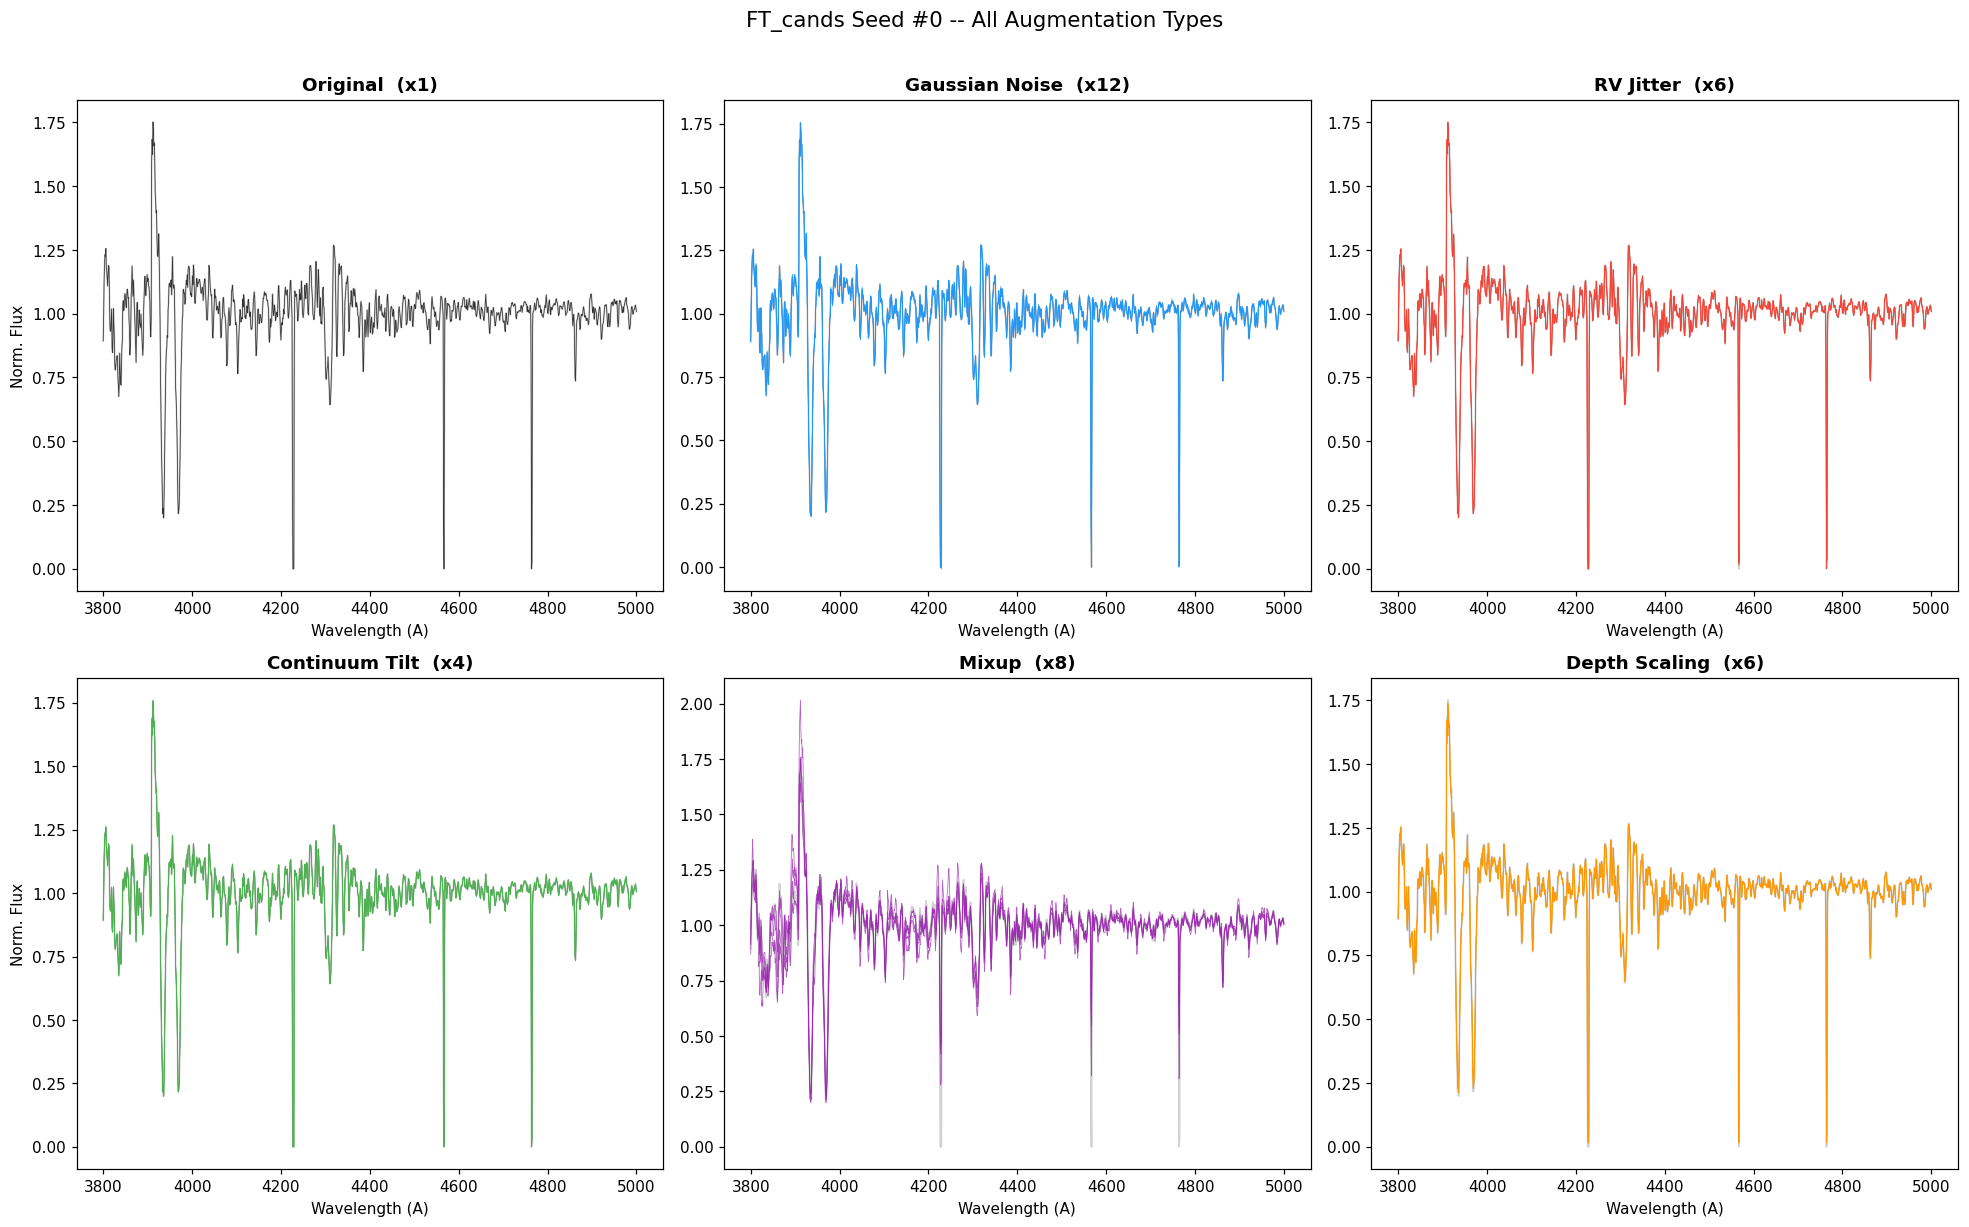

In [13]:
# Visualize augmentation: one seed + 6 types of variants
seed_idx = 0
n_ft = len(X_ft)
n_noise, n_rv, n_tilt, n_mixup, n_depth = 12, 6, 4, 8, 6

type_names = ["Original", "Gaussian Noise", "RV Jitter", "Continuum Tilt", "Mixup", "Depth Scaling"]
colors = ["black", "#2196F3", "#F44336", "#4CAF50", "#9C27B0", "#FF9800"]
multiples = [1, n_noise, n_rv, n_tilt, n_mixup, n_depth]

# Start offset of each type in X_ft_aug
starts = [0, n_ft]
for m in multiples[1:-1]:
    starts.append(starts[-1] + m * n_ft)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for i, (ax, name, color, mult) in enumerate(zip(axes.flat, type_names, colors, multiples)):
    # Original in gray for reference
    ax.plot(wave, X_ft[seed_idx], color="gray", alpha=0.35, lw=1.2)
    # Show up to 4 variants
    for j in range(min(mult, 4)):
        idx = starts[i] + seed_idx * mult + j
        if idx < len(X_ft_aug):
            ax.plot(wave, X_ft_aug[idx], color=color, lw=0.5, alpha=0.75)
    ax.set_title(f"{name}  (x{mult})", fontweight='bold')
    ax.set_xlabel("Wavelength (A)")
    if i % 3 == 0:
        ax.set_ylabel("Norm. Flux")

fig.suptitle(f"FT_cands Seed #{seed_idx} -- All Augmentation Types", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Conv1D Pipeline — Spectral Classifier\n
\n
Conv1D encoder on raw 1201-pixel spectra. Training 5-model ensemble takes ~1 min.

In [14]:
results_conv = run_pipeline(
    stars_csv=str(PROJECT_ROOT / "stars.csv"),
    spectra_folder=str(PROJECT_ROOT / "dr13_new"),
    gcs_folder=str(PROJECT_ROOT / "GCS"),
    encoder_type="conv1d",
    n_noise=12, n_rv=6, n_tilt=4, n_mixup=8, n_depth=6,
    latent_dim=64, dropout=0.35,
    n_epochs=80, n_ensemble=5,
    output_candidates_csv="BinaryClassifier/candidates_ft_conv1d.csv",
    device="cpu",
    verbose=True,
)

Step 1: Loading main LAMOST dataset (FT_cands labeled)
Loading LAMOST spectra (segment normalisation)


100%|██████████| 48440/48440 [05:07<00:00, 157.45it/s]



Pipeline summary:
  n_input: 48440
  n_after_dropna: 48440
  n_positive_labeled: 20
  n_loaded: 37086
  n_normalized_ok: 37086
  n_after_uid_dedup: 34123
  n_after_anomaly_filter: 33512
  n_positive (final): 15
  n_unlabeled (final): 33497
  Spectra shape: (33512, 5180)

  Full dataset: (33512, 5180) → sliced: (33512, 1201)
  Wavelength: 3800-5000 A (1201 pixels)
  FT_cands labeled: 15
  Unlabeled: 33497

  FT_cands seed: 15 spectra

Step 2: Augmenting FT_cands spectra
  Augmented: 555 positives (target ~555)
  Factor: x37.0

Step 3: Building validation sets
  CNstar validation: 92 spectra
  GCS validation:    29 spectra

Step 4: Negative sampling
  Negative pool: 33420 stars (99.7% of dataset)
  Train pos: 500 | Val: 55 pos + 55 neg

Step 5: Training ensemble (5 models, encoder=conv1d)

--- Model 1/5 (seed=42) ---
  Params: 339,633 | Pos: 500 Neg: 500 | Dim: 1201 | Type: conv1d
  Epoch  20/80 | loss: 0.1709 | acc: 0.719 | val_loss: 0.0515 | lr: 8.55e-05
  Epoch  40/80 | loss: 0.1902 

## 6. Conv1D — Training Curves

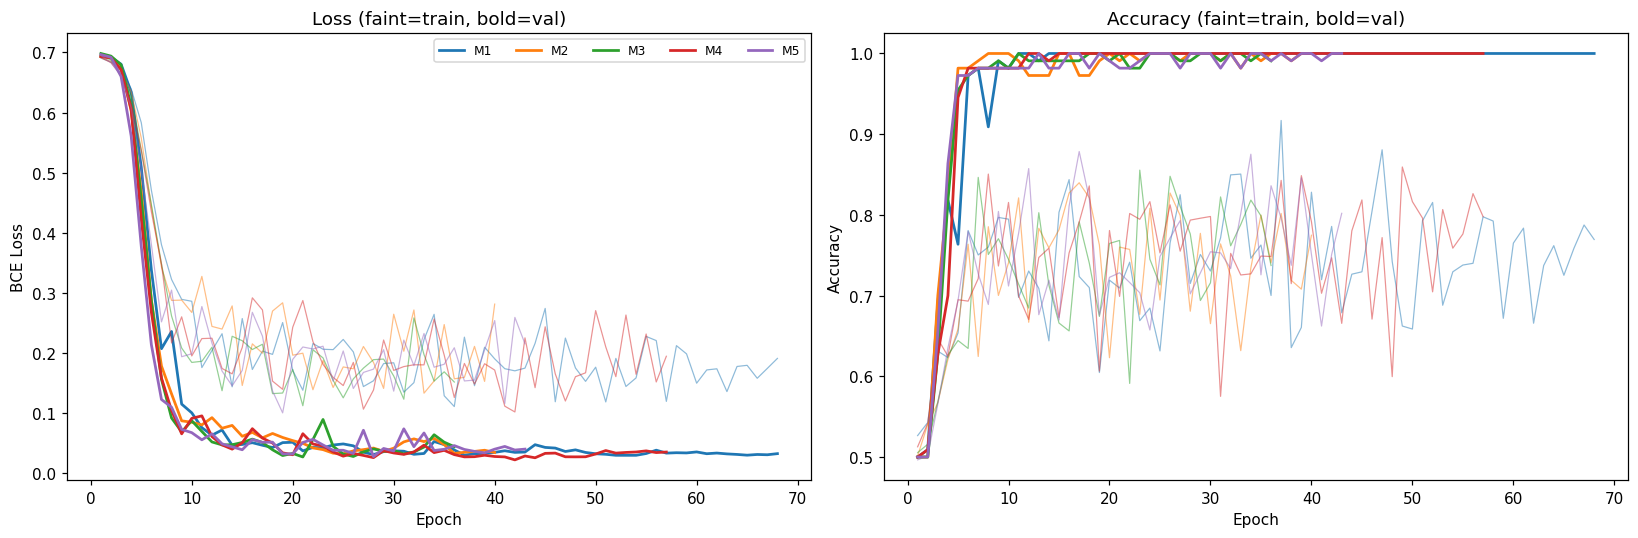

In [15]:
ensemble = results_conv["ensemble"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, trainer in enumerate(ensemble.trainers):
    h = trainer.history
    if not h:
        continue
    ep = [r["epoch"] for r in h]
    axes[0].plot(ep, [r["train_loss"] for r in h], lw=0.8, alpha=0.5, color=f"C{i}")
    axes[0].plot(ep, [r["val_loss"] for r in h], lw=1.8, color=f"C{i}", label=f"M{i+1}")
    axes[1].plot(ep, [r["train_acc"] for r in h], lw=0.8, alpha=0.5, color=f"C{i}")
    axes[1].plot(ep, [r["val_acc"] for r in h], lw=1.8, color=f"C{i}")

axes[0].set_title("Loss (faint=train, bold=val)"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].legend(fontsize=8, ncol=5)
axes[1].set_title("Accuracy (faint=train, bold=val)"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 7. Conv1D — Evaluation on Held-Out Test Sets

In [16]:
eval_conv = results_conv["results"]

print("=" * 55)
print("Conv1D Ensemble Evaluation")
print("=" * 55)
for name in ["GCS", "CNstar"]:
    if name not in eval_conv:
        continue
    r = eval_conv[name]
    print(f"\n--- {name} ({r['n_positive']} known CN / {r['n_total']} total) ---")
    print(f"  Mean prob (pos):  {r['prob_mean_pos']:.4f}")
    print(f"  Median rank pct:  {r['median_rank_pct']:.4f}  (<0.5 = better)")
    for k in [50, 100, 200]:
        pk = r.get(f"precision@{k}", 0)
        rk = r.get(f"recall@{k}", 0)
        print(f"  P@{k:3d}: {pk:.4f}  R@{k:3d}: {rk:.4f}")

if "unlabeled" in eval_conv:
    u = eval_conv["unlabeled"]
    print(f"\n--- Unlabeled ({u['n_total']:,} stars) ---")
    print(f"  Mean/Std:  {u['prob_mean']:.4f} / {u['prob_std']:.4f}")
    print(f"  P90/P95/P99: {u['prob_p90']:.4f} / {u['prob_p95']:.4f} / {u['prob_p99']:.4f}")

Conv1D Ensemble Evaluation

--- GCS (29 known CN / 29 total) ---
  Mean prob (pos):  0.0577
  Median rank pct:  0.5172  (<0.5 = better)
  P@ 50: 1.0000  R@ 50: 1.0000
  P@100: 1.0000  R@100: 1.0000
  P@200: 1.0000  R@200: 1.0000

--- CNstar (92 known CN / 92 total) ---
  Mean prob (pos):  0.5818
  Median rank pct:  0.5054  (<0.5 = better)
  P@ 50: 1.0000  R@ 50: 0.5435
  P@100: 1.0000  R@100: 1.0000
  P@200: 1.0000  R@200: 1.0000

--- Unlabeled (33,420 stars) ---
  Mean/Std:  0.0378 / 0.0693
  P90/P95/P99: 0.0651 / 0.1211 / 0.3792


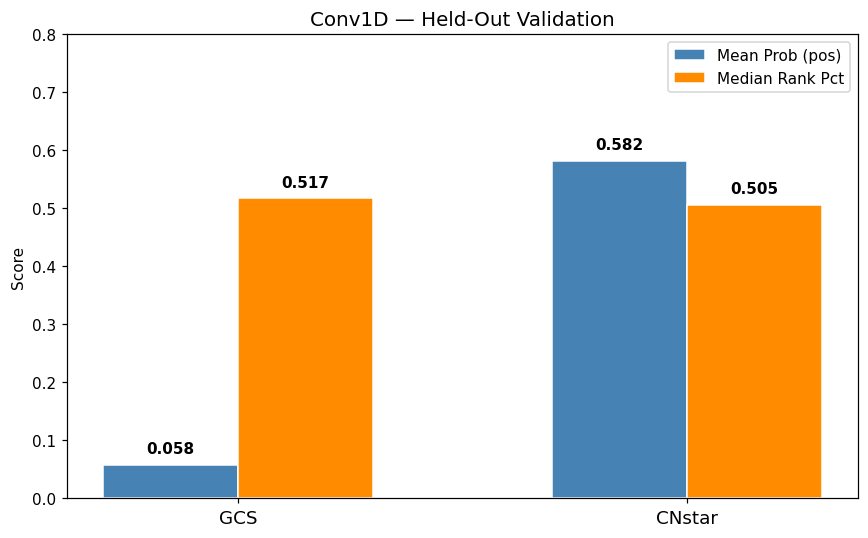

In [17]:
# Bar chart: Conv1D validation performance
fig, ax = plt.subplots(figsize=(8, 5))
names = ["GCS", "CNstar"]
x = np.arange(len(names))
w = 0.3

mean_probs = [eval_conv[n]["prob_mean_pos"] for n in names if n in eval_conv]
med_ranks = [eval_conv[n]["median_rank_pct"] for n in names if n in eval_conv]

bars1 = ax.bar(x - w/2, mean_probs, w, label="Mean Prob (pos)", color="steelblue", edgecolor="white")
bars2 = ax.bar(x + w/2, med_ranks, w, label="Median Rank Pct", color="darkorange", edgecolor="white")

for bar, val in zip(bars1, mean_probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
for bar, val in zip(bars2, med_ranks):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=12)
ax.set_ylabel("Score"); ax.set_title("Conv1D — Held-Out Validation", fontsize=13)
ax.legend(fontsize=10); ax.set_ylim(0, 0.8)
plt.tight_layout(); plt.show()

## 8. Conv1D — Probability Distribution & Top Candidates

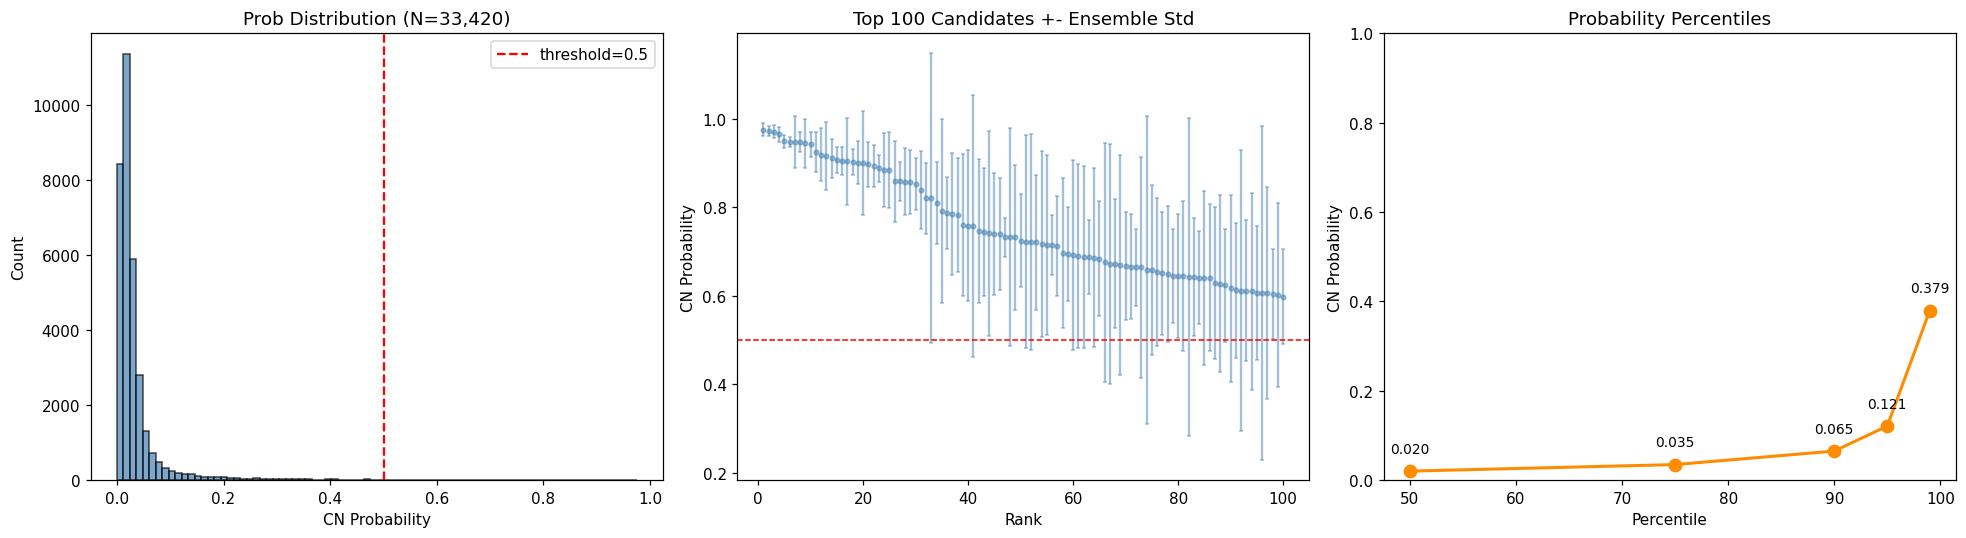

In [18]:
c_df = results_conv["candidates_df"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram of all probabilities
axes[0].hist(c_df["cn_prob"], bins=80, edgecolor="k", alpha=0.7, color="steelblue")
axes[0].axvline(0.5, color="red", ls="--", lw=1.5, label="threshold=0.5")
axes[0].set_xlabel("CN Probability"); axes[0].set_ylabel("Count")
axes[0].set_title(f"Prob Distribution (N={len(c_df):,})"); axes[0].legend()

# 2. Top 100 with ensemble std
top100 = c_df.head(100)
axes[1].errorbar(range(1, 101), top100["cn_prob"], yerr=top100["cn_std"],
                fmt="o", ms=3, alpha=0.5, color="steelblue", capsize=1)
axes[1].axhline(0.5, color="red", ls="--", lw=1)
axes[1].set_xlabel("Rank"); axes[1].set_ylabel("CN Probability")
axes[1].set_title("Top 100 Candidates +- Ensemble Std")

# 3. P90/P95/P99 markers
perc = [50, 75, 90, 95, 99]
vals = [np.percentile(c_df["cn_prob"], p) for p in perc]
axes[2].plot(perc, vals, "o-", color="darkorange", lw=2, markersize=8)
for p, v in zip(perc, vals):
    axes[2].annotate(f"{v:.3f}", (p, v), textcoords="offset points", xytext=(0, 12), ha="center", fontsize=9)
axes[2].set_xlabel("Percentile"); axes[2].set_ylabel("CN Probability")
axes[2].set_title("Probability Percentiles"); axes[2].set_ylim(0, 1)

plt.tight_layout(); plt.show()

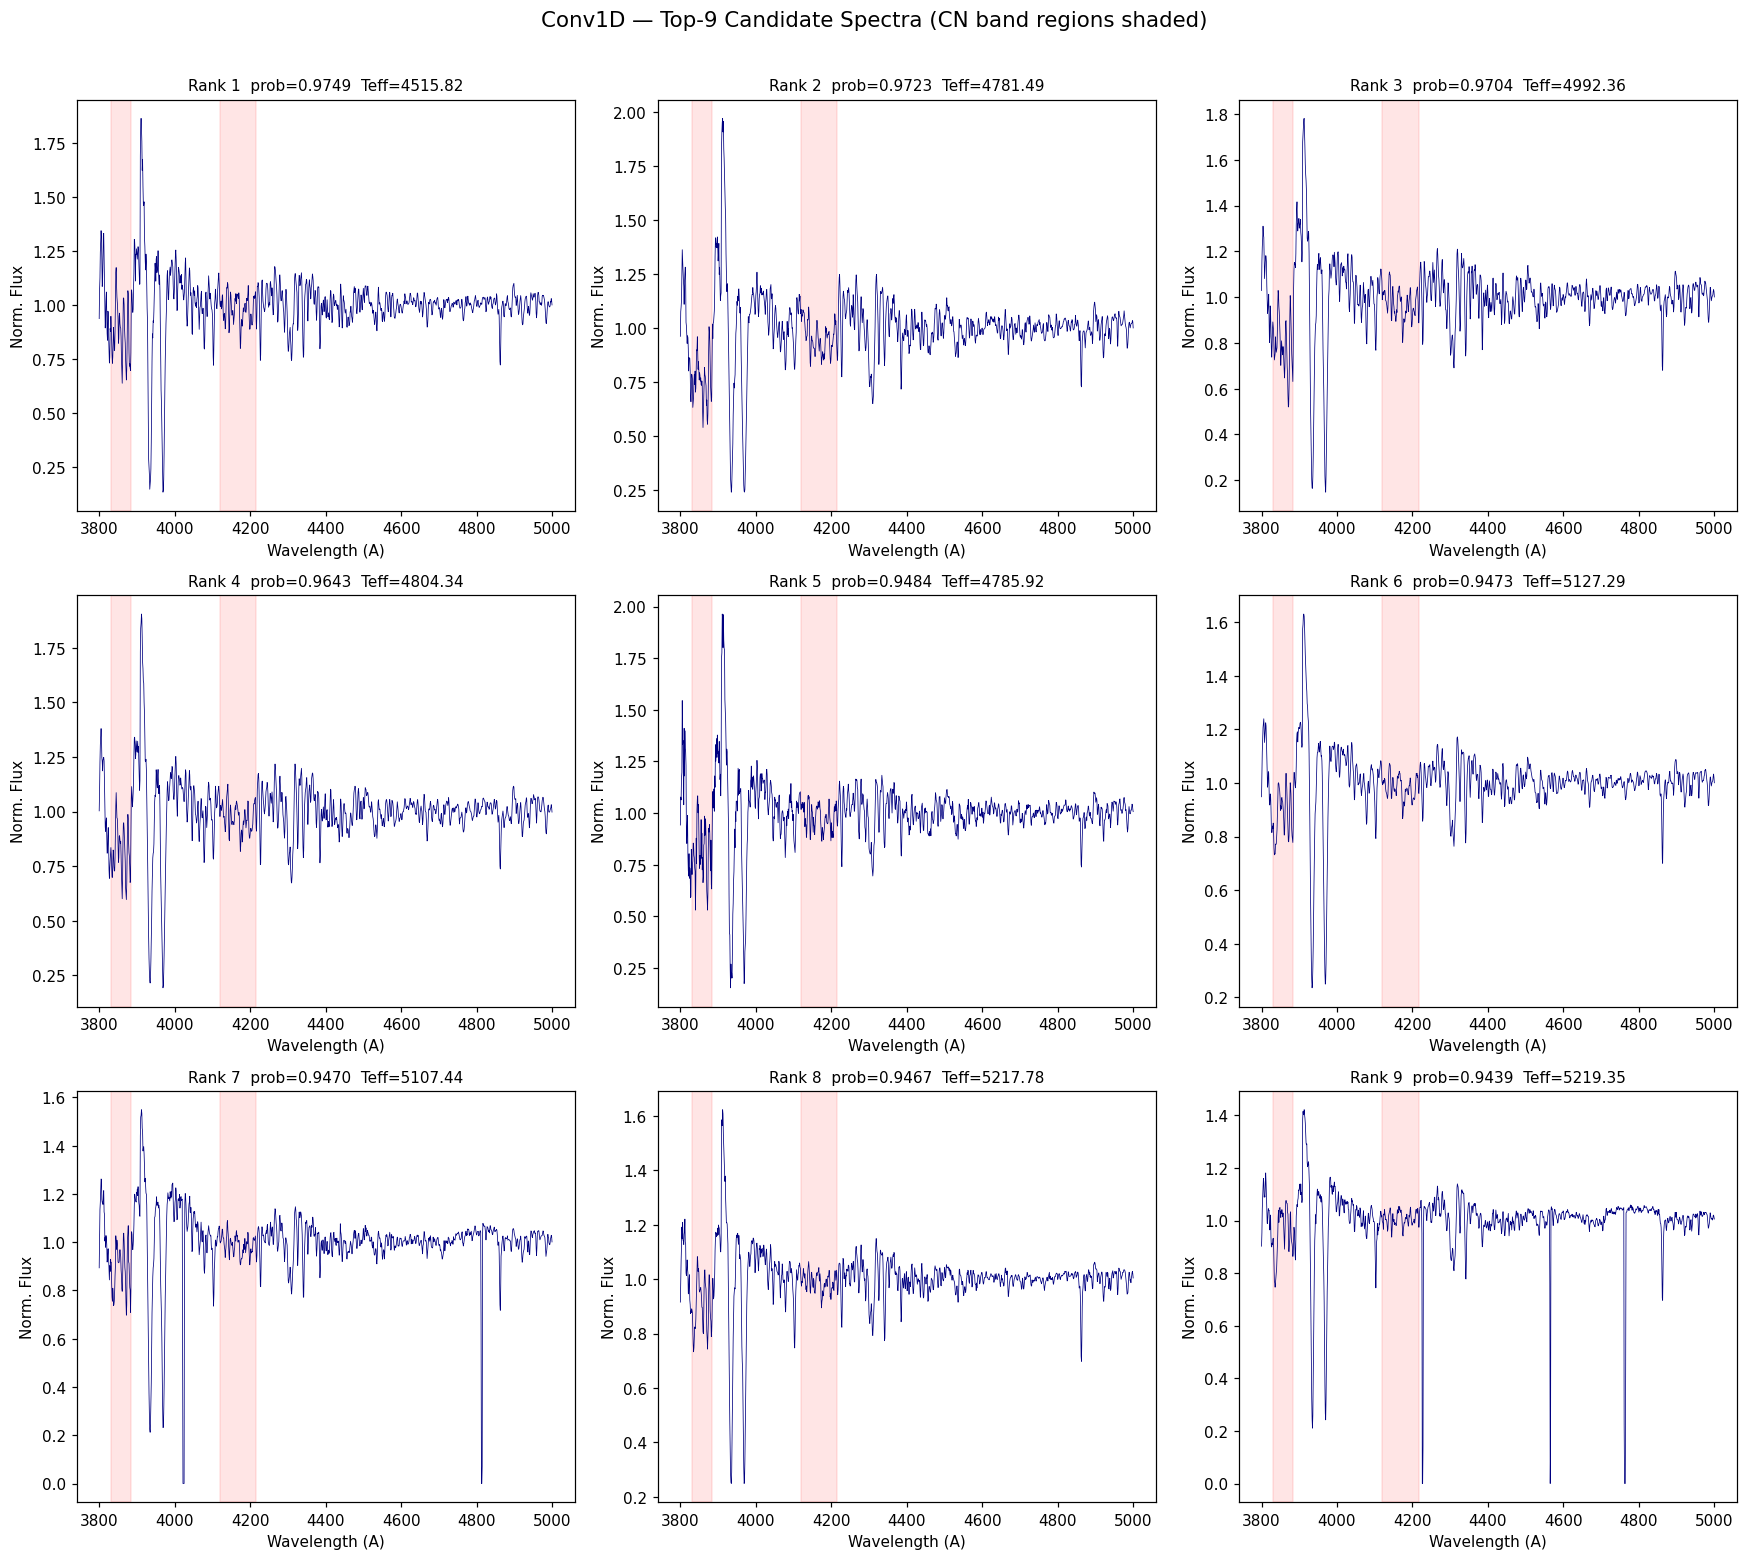

In [19]:
# Top candidate spectra
top9 = c_df.head(9)
meta_fp = dataset.meta["filepath"].values

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for i, (ax, (_, row)) in enumerate(zip(axes.flat, top9.iterrows())):
    fp = row["filepath"]
    matches = np.where(meta_fp == fp)[0]
    spec_idx = matches[0] if len(matches) > 0 else 0
    
    ax.plot(wave, dataset.X[spec_idx], lw=0.5, color="navy")
    # Mark CN band regions
    for bs, be in [(3830, 3883), (4120, 4216)]:
        ax.axvspan(bs, be, alpha=0.1, color="red")
    ax.set_title(f"Rank {i+1}  prob={row['cn_prob']:.4f}  Teff={row.get('teff','?')}", fontsize=10)
    ax.set_xlabel("Wavelength (A)")
    ax.set_ylabel("Norm. Flux")

fig.suptitle("Conv1D — Top-9 Candidate Spectra (CN band regions shaded)", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 9. MLP Pipeline — Physics Feature Classifier\n
\n
MLP on 12-D physics features (teff, logg, feh, CN indices, delta features, PCA).\n
Much faster training (~2s/model vs ~15s for Conv1D).

In [20]:
results_mlp = run_pipeline(
    stars_csv=str(PROJECT_ROOT / "stars.csv"),
    spectra_folder=str(PROJECT_ROOT / "dr13_new"),
    gcs_folder=str(PROJECT_ROOT / "GCS"),
    encoder_type="mlp",
    n_noise=12, n_rv=6, n_tilt=4, n_mixup=8, n_depth=6,
    noise_std=0.005,
    latent_dim=64, dropout=0.35,
    n_epochs=80, n_ensemble=5,
    output_candidates_csv="BinaryClassifier/candidates_ft_mlp.csv",
    device="cpu",
    verbose=True,
)

Step 1: Loading main LAMOST dataset (FT_cands labeled)
Loading LAMOST spectra (segment normalisation)


100%|██████████| 48440/48440 [04:54<00:00, 164.36it/s]



Pipeline summary:
  n_input: 48440
  n_after_dropna: 48440
  n_positive_labeled: 20
  n_loaded: 37086
  n_normalized_ok: 37086
  n_after_uid_dedup: 34123
  n_after_anomaly_filter: 33512
  n_positive (final): 15
  n_unlabeled (final): 33497
  Spectra shape: (33512, 5180)

  Full dataset: (33512, 5180) → sliced: (33512, 1201)
  Wavelength: 3800-5000 A (1201 pixels)
  FT_cands labeled: 15
  Unlabeled: 33497

  FT_cands seed: 15 spectra

Step 2: Augmenting FT_cands spectra
  Augmented: 555 positives (target ~555)
  Factor: x37.0

Step 3: Building validation sets
  CNstar validation: 92 spectra
  GCS validation:    29 spectra

Step 4: Negative sampling
  Negative pool: 33420 stars (99.7% of dataset)
  Train pos: 500 | Val: 55 pos + 55 neg

Step 5: Training ensemble (5 models, encoder=mlp)
  Computing physics features...
  Masked-cluster: 45 clusters (PCA-25 on masked spectra)

--- Model 1/5 (seed=42) ---
  Params: 5,905 | Pos: 500 Neg: 500 | Dim: 12 | Type: mlp
  Epoch  20/80 | loss: 0.578

## 10. MLP — Training Curves

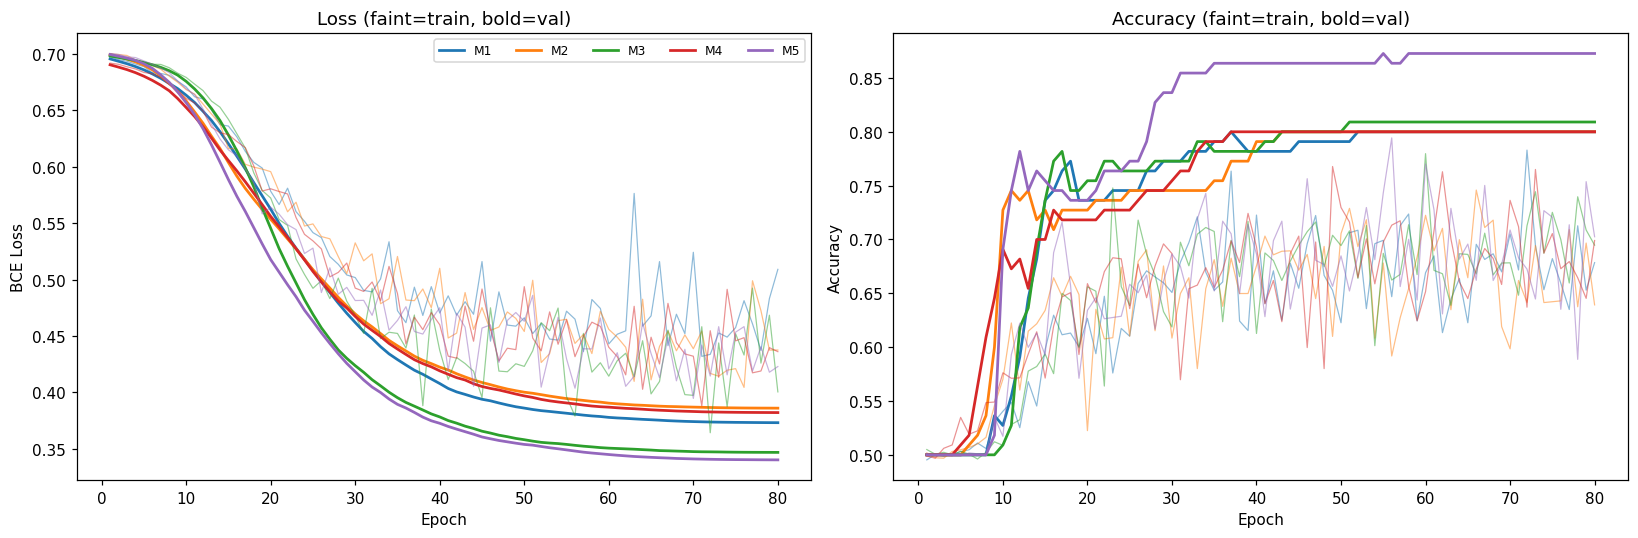

In [21]:
ensemble_mlp = results_mlp["ensemble"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, trainer in enumerate(ensemble_mlp.trainers):
    h = trainer.history
    if not h:
        continue
    ep = [r["epoch"] for r in h]
    axes[0].plot(ep, [r["train_loss"] for r in h], lw=0.8, alpha=0.5, color=f"C{i}")
    axes[0].plot(ep, [r["val_loss"] for r in h], lw=1.8, color=f"C{i}", label=f"M{i+1}")
    axes[1].plot(ep, [r["train_acc"] for r in h], lw=0.8, alpha=0.5, color=f"C{i}")
    axes[1].plot(ep, [r["val_acc"] for r in h], lw=1.8, color=f"C{i}")

axes[0].set_title("Loss (faint=train, bold=val)"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].legend(fontsize=8, ncol=5)
axes[1].set_title("Accuracy (faint=train, bold=val)"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 11. MLP — Evaluation & Conv1D Comparison

In [22]:
eval_mlp = results_mlp["results"]

print("=" * 55)
print("MLP Ensemble Evaluation")
print("=" * 55)
for name in ["GCS", "CNstar"]:
    if name not in eval_mlp:
        continue
    r = eval_mlp[name]
    print(f"\n--- {name} ({r['n_positive']} known CN / {r['n_total']} total) ---")
    print(f"  Mean prob (pos):  {r['prob_mean_pos']:.4f}")
    print(f"  Median rank pct:  {r['median_rank_pct']:.4f}")

if "unlabeled" in eval_mlp:
    u = eval_mlp["unlabeled"]
    print(f"\n--- Unlabeled ({u['n_total']:,} stars) ---")
    print(f"  Mean/Srd:  {u['prob_mean']:.4f} / {u['prob_std']:.4f}")
    print(f"  P90/P95/P99: {u['prob_p90']:.4f} / {u['prob_p95']:.4f} / {u['prob_p99']:.4f}")

MLP Ensemble Evaluation

--- GCS (29 known CN / 29 total) ---
  Mean prob (pos):  0.2277
  Median rank pct:  0.5172

--- CNstar (92 known CN / 92 total) ---
  Mean prob (pos):  0.8222
  Median rank pct:  0.5054

--- Unlabeled (33,420 stars) ---
  Mean/Srd:  0.2272 / 0.1972
  P90/P95/P99: 0.5273 / 0.6738 / 0.8605


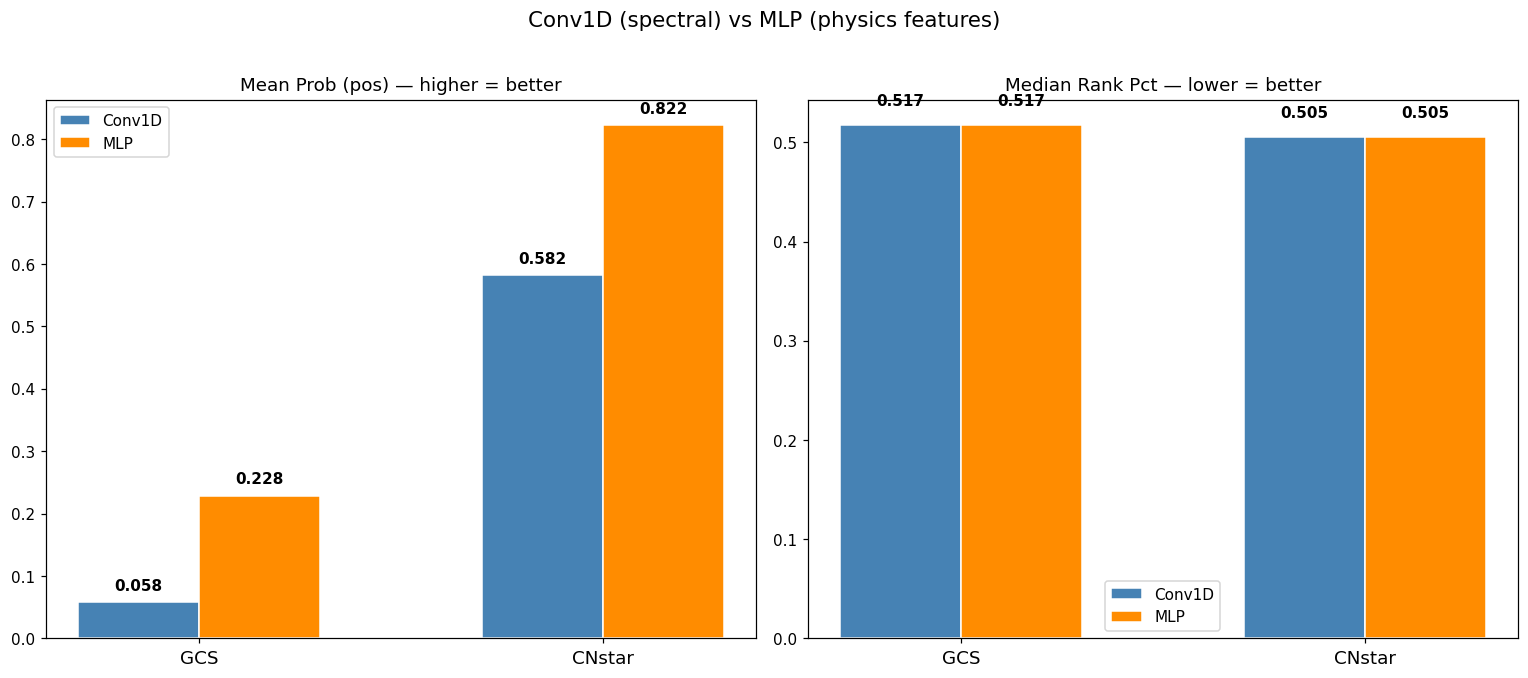

In [23]:
# Side-by-side comparison: Conv1D vs MLP
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric_key, metric_name in [
    (axes[0], "prob_mean_pos", "Mean Prob (pos) — higher = better"),
    (axes[1], "median_rank_pct", "Median Rank Pct — lower = better"),
]:
    names_list = ["GCS", "CNstar"]
    x = np.arange(len(names_list)); w = 0.3
    
    cv = [eval_conv[n][metric_key] for n in names_list if n in eval_conv]
    mv = [eval_mlp[n][metric_key] for n in names_list if n in eval_mlp]
    
    b1 = ax.bar(x - w/2, cv, w, label="Conv1D", color="steelblue", edgecolor="white")
    b2 = ax.bar(x + w/2, mv, w, label="MLP", color="darkorange", edgecolor="white")
    
    for bar, val in zip(b1, cv):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.3f}", ha="center", fontweight="bold")
    for bar, val in zip(b2, mv):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.3f}", ha="center", fontweight="bold")
    
    ax.set_xticks(x); ax.set_xticklabels(names_list, fontsize=12)
    ax.set_title(metric_name, fontsize=12)
    ax.legend(fontsize=10)

fig.suptitle("Conv1D (spectral) vs MLP (physics features)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

In [24]:
# Candidate overlap: top-200 from each method
c_conv = results_conv["candidates_df"].head(200)
c_mlp = results_mlp["candidates_df"].head(200)

conv_pos = set(zip(c_conv["ra"].round(4), c_conv["dec"].round(4)))
mlp_pos = set(zip(c_mlp["ra"].round(4), c_mlp["dec"].round(4)))
shared = conv_pos & mlp_pos

print(f"Top-200 overlap: {len(shared)} / 200  ({len(shared)/2:.0f}%)")
print(f"Conv1D only: {len(conv_pos - mlp_pos)}  |  MLP only: {len(mlp_pos - conv_pos)}")

Top-200 overlap: 31 / 200  (16%)
Conv1D only: 169  |  MLP only: 168


## 12. Top Candidates Export\n
\n
Final candidate list using the best-performing model (MLP).

In [25]:
final_cands = results_mlp["candidates_df"]

# Show top-15
cols_show = ["cn_prob", "cn_std", "ra", "dec", "teff", "logg", "feh"]
cols_avail = [c for c in cols_show if c in final_cands.columns]
print(f"Top-15 MLP candidates (of {len(final_cands):,} total):")
display(final_cands[cols_avail].head(15).style
        .background_gradient(subset=["cn_prob"], cmap="OrRd")
        .format({"cn_prob": "{:.4f}", "cn_std": "{:.4f}", "ra": "{:.3f}", "dec": "{:.3f}"}))

Top-15 MLP candidates (of 33,420 total):


,cn_prob,cn_std,ra,dec,teff,logg,feh
22239,1.0000,0.0000,243.451,-0.437,0.001726,0.017782,1.136755
9236,0.9998,0.0003,117.445,19.822,0.190092,0.079268,1.283217
1006,0.9984,0.0018,130.469,16.307,0.986615,1.174484,-0.806921
11720,0.9969,0.0041,194.873,38.622,0.412509,0.100404,0.746189
27457,0.9962,0.0034,31.190,-2.601,-0.371399,-0.910269,-0.690972
32025,0.9953,0.0041,129.665,2.672,-0.602560,-0.745026,0.178648
9375,0.9952,0.0050,36.540,43.554,-1.406369,-0.370347,1.234396
11548,0.9938,0.0070,263.558,28.316,-0.136479,0.403990,0.618034
576,0.9918,0.0075,359.097,17.230,1.113163,1.343570,-1.307334
10776,0.9890,0.0084,176.308,45.083,1.080721,1.093785,-1.676540


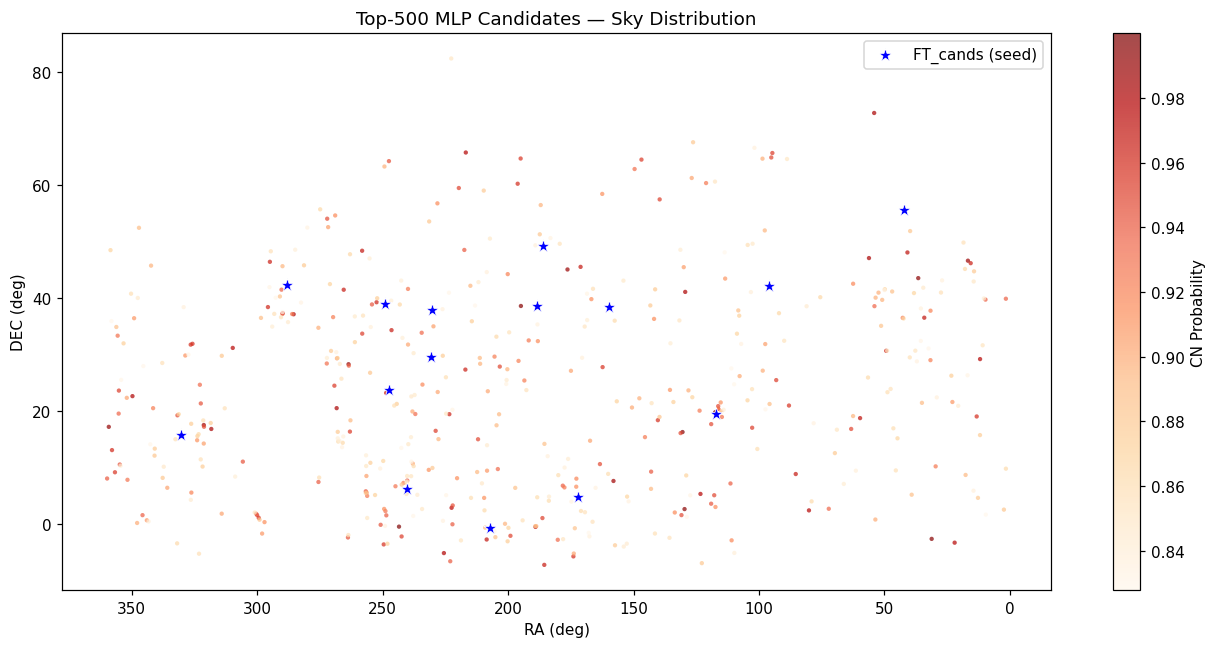

In [26]:
# Scatter: RA/Dec of top candidates, colored by probability
fig, ax = plt.subplots(figsize=(12, 6))
top500 = final_cands.head(500)
sc = ax.scatter(top500["ra"], top500["dec"], c=top500["cn_prob"],
                cmap="OrRd", s=8, alpha=0.7, edgecolors="none")
plt.colorbar(sc, ax=ax, label="CN Probability")

# Overlay known CN stars
known_cn = dataset.meta.iloc[dataset.y == 1]
ax.scatter(known_cn["ra"], known_cn["dec"], c="blue", marker="*", s=80,
           edgecolors="white", linewidth=0.5, label="FT_cands (seed)", zorder=5)

ax.set_xlabel("RA (deg)"); ax.set_ylabel("DEC (deg)")
ax.set_title("Top-500 MLP Candidates — Sky Distribution")
ax.legend(fontsize=10)
ax.invert_xaxis()  # RA increases right-to-left on sky
plt.tight_layout(); plt.show()